In [28]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns


In [29]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,United States,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8804 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8804 non-null   object
 1   type          8804 non-null   object
 2   title         8804 non-null   object
 3   director      8804 non-null   object
 4   cast          8804 non-null   object
 5   country       8804 non-null   object
 6   date_added    8804 non-null   object
 7   release_year  8804 non-null   int64 
 8   rating        8804 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8804 non-null   object
 11  description   8804 non-null   object
dtypes: int64(1), object(11)
memory usage: 894.2+ KB


In [31]:
df.describe(include='all')
df.head()
df.shape

(8804, 12)

In [33]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [17]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Not Available")

df["country"] = df["country"].fillna(df["country"].mode()[0])
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

df["date_added"] = df["date_added"].fillna(df["date_added"].mode()[0])
df = df.dropna(subset=["duration"])

In [34]:
print(df.duplicated().sum())

df = df.drop_duplicates()

print(df.duplicated().sum())

0
0


In [35]:
df.columns = df.columns.str.lower().str.replace(" ","_")

df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

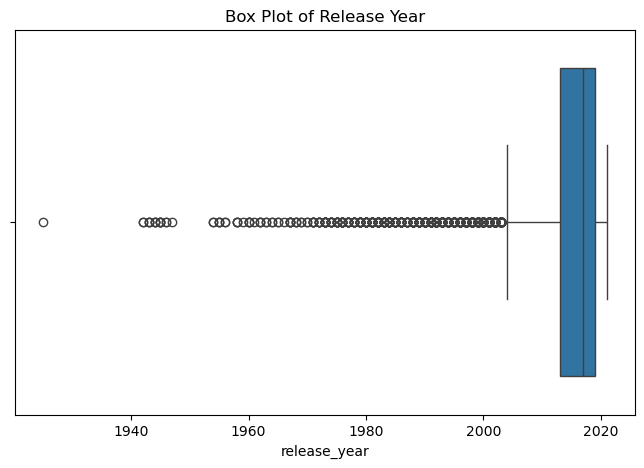

In [47]:


import matplotlib.pyplot as plt
import seaborn as sns

# Create a box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["release_year"])

# Add title
plt.title("Box Plot of Release Year")

# Show the plot
plt.show()

In [48]:
Q1 = df["release_year"].quantile(0.25)
Q3 = df["release_year"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["release_year"] < lower) | (df["release_year"] > upper)]

print(outliers.shape)

(719, 12)


In [50]:
df = df[(df["release_year"] >= lower) &
        (df["release_year"] <= upper)]

In [51]:
df = pd.get_dummies(df, columns=["type"], drop_first=True)

In [54]:
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 8085 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8085 non-null   object
 1   title         8085 non-null   object
 2   director      8085 non-null   object
 3   cast          8085 non-null   object
 4   country       8085 non-null   object
 5   date_added    8085 non-null   object
 6   release_year  8085 non-null   int64 
 7   rating        8085 non-null   object
 8   duration      8085 non-null   object
 9   listed_in     8085 non-null   object
 10  description   8085 non-null   object
 11  type_TV Show  8085 non-null   bool  
dtypes: bool(1), int64(1), object(10)
memory usage: 765.9+ KB


,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type_TV Show
0,s1,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",False
1,s2,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",True
2,s3,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,True
3,s4,Jailbirds New Orleans,Unknown,Not Available,United States,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",True
4,s5,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,True


In [55]:
df.to_csv("cleaned_netflix_dataset.csv", index=False)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!
